In [1]:
import pandas as pd

files = {
    "GBT": "gbt_daily_returns.csv",
    "RAF": "backtest_results_k10.csv",
    "DNN": "dnn_backtest_results_k10.csv",
    "ENS": "ensemble_portfolio_returns.csv",
    "MKT": "sp500_returns.csv",
    "VIX": "VIXCLS.csv",
}

for name, f in files.items():
    df = pd.read_csv(f)
    print(f"{name}: {df.columns.tolist()}")
    print(df.head(1).to_string())
    print()

GBT: ['date', 'period', 'long_ret', 'short_ret', 'raw_return', 'net_return']
         date  period  long_ret  short_ret  raw_return  net_return
0  1992-12-16       1 -0.004106   0.018915    -0.02302    -0.02502

RAF: ['date', 'long_ret', 'short_ret', 'raw_ret', 'net_ret', 'n_stocks']
         date  long_ret  short_ret   raw_ret   net_ret  n_stocks
0  1992-12-17  0.023377    0.00416  0.019217  0.017217       493

DNN: ['date', 'long_ret', 'short_ret', 'raw_ret', 'net_ret', 'n_stocks']
         date  long_ret  short_ret  raw_ret  net_ret  n_stocks
0  1992-12-16  0.007438   0.029928 -0.02249 -0.02449       500

ENS: ['date', 'k', 'portfolio_ret', 'long_ret', 'short_ret', 'n_long', 'n_short', 'ensemble', 'period']
         date   k  portfolio_ret  long_ret  short_ret  n_long  n_short ensemble  period
0  1992-12-17  10        0.02196  0.023159   0.001199      10       10     ENS1       1

MKT: ['permno', 'date', 'ret']
   permno        date       ret
0   10104  1990-01-02  0.032086

VIX: ['

In [3]:
import pandas as pd

gbt = pd.read_csv("gbt_daily_returns.csv", parse_dates=["date"])
raf = pd.read_csv("backtest_results_k10.csv", parse_dates=["date"])
dnn = pd.read_csv("dnn_backtest_results_k10.csv", parse_dates=["date"])
ens = pd.read_csv("ensemble_portfolio_returns.csv", parse_dates=["date"])
ens10 = ens[(ens["k"]==10) & (ens["ensemble"]=="ENS1")]

for name, df in [("GBT",gbt),("RAF",raf),("DNN",dnn),("ENS",ens10)]:
    print(f"{name}: {df['date'].min().date()} → {df['date'].max().date()}, n={len(df)}")

# ENS portfolio_ret均值
print(f"\nENS portfolio_ret mean: {ens10['portfolio_ret'].mean():.6f}")

GBT: 1992-12-16 → 2024-09-24, n=8000
RAF: 1992-12-17 → 2024-09-25, n=8000
DNN: 1992-12-16 → 2024-09-24, n=8000
ENS: 1992-12-17 → 2024-09-24, n=7999

ENS portfolio_ret mean: 0.002791


# 两个fig 论文区间+extend

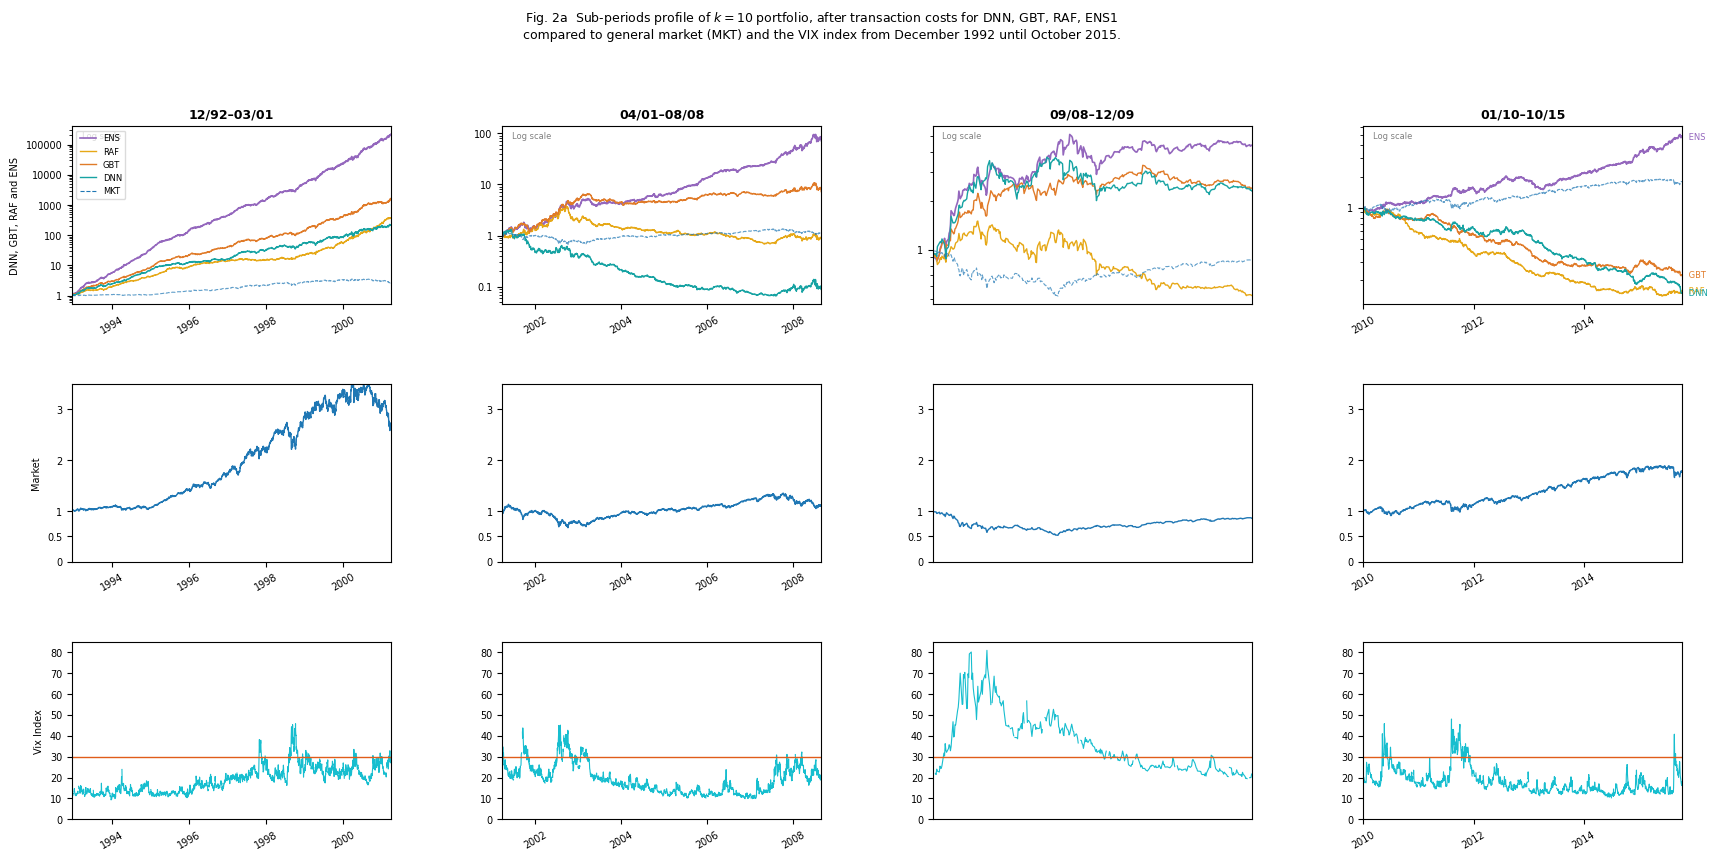

Saved: fig2a_paper.pdf / .png


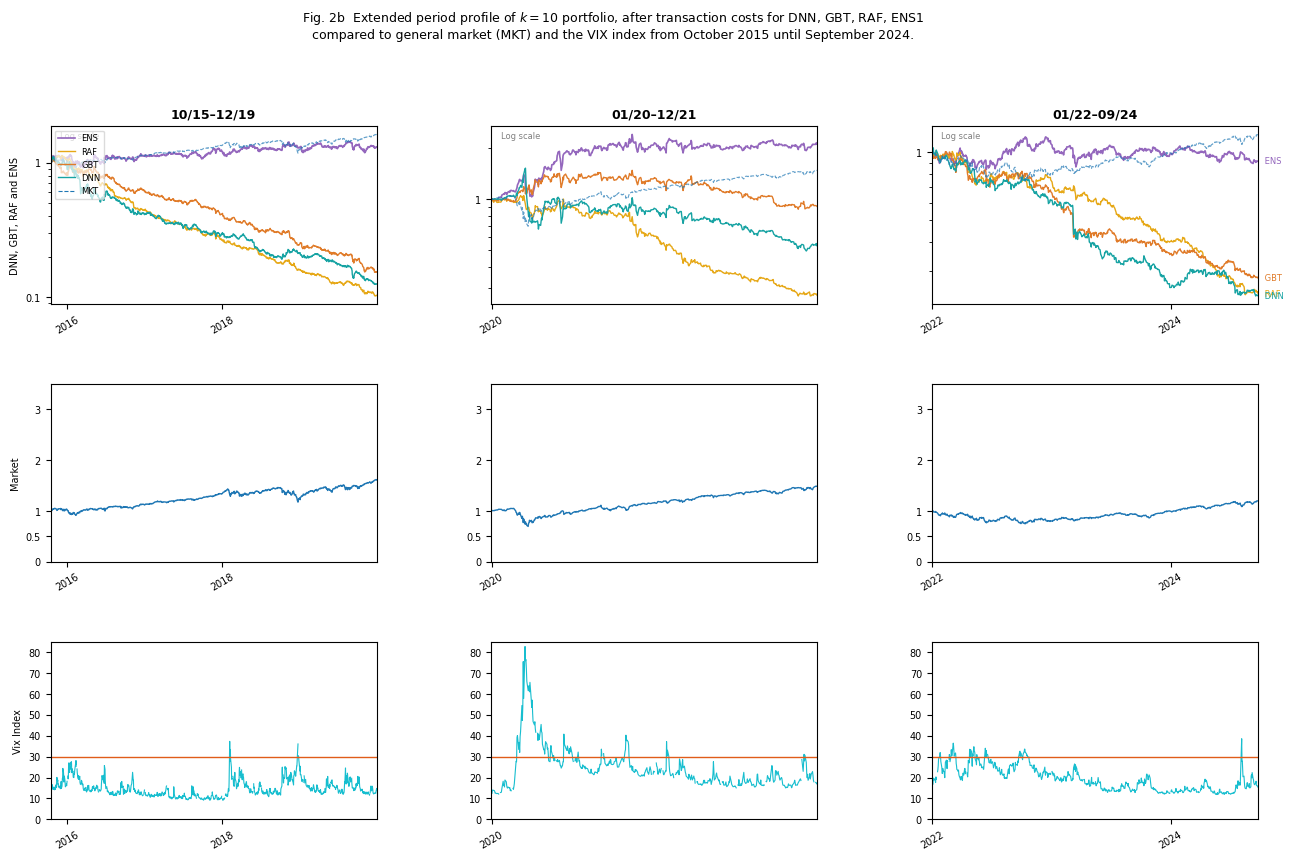

Saved: fig2b_extended.pdf / .png


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator
import warnings
warnings.filterwarnings("ignore")

# ── 1. 读取数据 ────────────────────────────────────────────────
gbt     = pd.read_csv("gbt_daily_returns.csv", parse_dates=["date"])
raf     = pd.read_csv("backtest_results_k10.csv", parse_dates=["date"])
dnn     = pd.read_csv("dnn_backtest_results_k10.csv", parse_dates=["date"])
ens_raw = pd.read_csv("ensemble_portfolio_returns.csv", parse_dates=["date"])
mkt     = pd.read_csv("crsp_market_index.csv", parse_dates=["date"])
vix     = pd.read_csv("VIXCLS.csv", parse_dates=["observation_date"])

# ── 2. 统一列名 ───────────────────────────────────────────────
gbt = gbt.rename(columns={"net_return":"net_ret"})[["date","net_ret"]]
raf = raf[["date","net_ret"]]
dnn = dnn[["date","net_ret"]]
ens = (ens_raw[(ens_raw["k"]==10) & (ens_raw["ensemble"]=="ENS1")]
       [["date","portfolio_ret"]]
       .rename(columns={"portfolio_ret":"net_ret"}))
mkt = mkt[["date","sprtrn"]].rename(columns={"sprtrn":"net_ret"})
vix = vix.rename(columns={"observation_date":"date","VIXCLS":"vix"})
vix["vix"] = pd.to_numeric(vix["vix"], errors="coerce")

for df in [gbt, raf, dnn, ens, mkt, vix]:
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)

# ── 3. 颜色 ───────────────────────────────────────────────────
colors = {
    "ENS": "#9467bd",   # 紫色
    "RAF": "#e6a817",   # 金黄色
    "GBT": "#e07b29",   # 橙色
    "DNN": "#17a3a3",   # 青色
    "MKT": "#1f77b4",   # 蓝色
}

# ── 4. 通用画图函数 ───────────────────────────────────────────
def plot_subperiods(cuts, titles, figname, suptitle,
                    mkt_yticks, mkt_ylim, vix_ylim):
    n = len(titles)
    fig = plt.figure(figsize=(5*n, 9))
    gs  = gridspec.GridSpec(3, n, figure=fig, hspace=0.45, wspace=0.35)

    for i, (t0, t1, title) in enumerate(zip(cuts[:-1], cuts[1:], titles)):

        def sub(df):
            return df[(df["date"]>=t0)&(df["date"]<=t1)].copy().reset_index(drop=True)

        def rebase(df, col="net_ret"):
            d = df.copy()
            d["cum"] = (1 + d[col]).cumprod()
            return d

        g=rebase(sub(gbt)); r=rebase(sub(raf)); d=rebase(sub(dnn))
        e=rebase(sub(ens)); m=rebase(sub(mkt))
        sv = sub(vix)

        # ── Row 0: 策略累计收益 log scale ──────────────────────
        ax0 = fig.add_subplot(gs[0, i])
        ax0.plot(e["date"], e["cum"], color=colors["ENS"], lw=1.2)
        ax0.plot(r["date"], r["cum"], color=colors["RAF"], lw=1.0)
        ax0.plot(g["date"], g["cum"], color=colors["GBT"], lw=1.0)
        ax0.plot(d["date"], d["cum"], color=colors["DNN"], lw=1.0)
        ax0.plot(m["date"], m["cum"], color=colors["MKT"], lw=0.8,
                 ls="--", alpha=0.7)
        ax0.set_yscale("log")
        ax0.set_xlim(t0, t1)
        ax0.set_title(title, fontsize=9, fontweight="bold")
        ax0.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
        ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:g}"))
        ax0.yaxis.set_minor_formatter(plt.NullFormatter())
        ax0.xaxis.set_major_locator(mdates.YearLocator(2))
        ax0.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax0.xaxis.get_majorticklabels(), rotation=30, fontsize=7)
        ax0.tick_params(axis='y', labelsize=7)
        ax0.text(0.03, 0.97, "Log scale", transform=ax0.transAxes,
                 fontsize=6, va='top', color='gray')
        # 每列都显示y轴标签
        if i == 0:
            ax0.set_ylabel("DNN, GBT, RAF and ENS", fontsize=7)
            legend_elements = [
                Line2D([0],[0], color=colors["ENS"], lw=1.2, label="ENS"),
                Line2D([0],[0], color=colors["RAF"], lw=1.0, label="RAF"),
                Line2D([0],[0], color=colors["GBT"], lw=1.0, label="GBT"),
                Line2D([0],[0], color=colors["DNN"], lw=1.0, label="DNN"),
                Line2D([0],[0], color=colors["MKT"], lw=0.8,
                       ls="--", label="MKT"),
            ]
            ax0.legend(handles=legend_elements, fontsize=6,
                       loc="upper left", framealpha=0.7)
        # 右端文字标注（最后一列）
        if i == n - 1:
            for label, series in [("ENS",e),("RAF",r),("GBT",g),("DNN",d)]:
                ax0.annotate(f" {label}",
                             xy=(series["date"].iloc[-1],
                                 series["cum"].iloc[-1]),
                             fontsize=6, color=colors[label], va='center',
                             xytext=(3,0), textcoords='offset points',
                             clip_on=False)

        # ── Row 1: Market LINEAR scale，统一y轴，每列都有刻度 ──
        ax1 = fig.add_subplot(gs[1, i])
        ax1.plot(m["date"], m["cum"], color=colors["MKT"], lw=1.0)
        ax1.set_xlim(t0, t1)
        ax1.set_ylim(mkt_ylim)
        ax1.set_yticks(mkt_yticks)
        ax1.set_yticklabels([str(t) for t in mkt_yticks], fontsize=7)
        ax1.xaxis.set_major_locator(mdates.YearLocator(2))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, fontsize=7)
        ax1.tick_params(axis='y', labelsize=7)
        if i == 0:
            ax1.set_ylabel("Market", fontsize=7)

        # ── Row 2: VIX，统一y轴，每列都有刻度 ────────────────
        ax2 = fig.add_subplot(gs[2, i])
        ax2.plot(sv["date"], sv["vix"], color="#17becf", lw=0.8)
        ax2.axhline(30, color="#e05c1a", lw=1.0)
        ax2.set_xlim(t0, t1)
        ax2.set_ylim(vix_ylim)
        ax2.xaxis.set_major_locator(mdates.YearLocator(2))
        ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, fontsize=7)
        ax2.tick_params(axis='y', labelsize=7)
        if i == 0:
            ax2.set_ylabel("Vix Index", fontsize=7)

    plt.suptitle(suptitle, fontsize=9, y=1.01)
    fig.subplots_adjust(right=0.93)
    plt.savefig(f"{figname}.pdf", bbox_inches="tight", dpi=150)
    plt.savefig(f"{figname}.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {figname}.pdf / .png")


# ── 5. Fig 2a：论文区间 ───────────────────────────────────────
cuts_paper = [
    pd.Timestamp("1992-12-16"),
    pd.Timestamp("2001-03-31"),
    pd.Timestamp("2008-08-29"),
    pd.Timestamp("2009-12-31"),
    pd.Timestamp("2015-10-14"),
]
titles_paper = ["12/92–03/01", "04/01–08/08", "09/08–12/09", "01/10–10/15"]

plot_subperiods(
    cuts_paper, titles_paper,
    figname="fig2a_paper",
    suptitle=(
        "Fig. 2a  Sub-periods profile of $k=10$ portfolio, after transaction costs "
        "for DNN, GBT, RAF, ENS1\n"
        "compared to general market (MKT) and the VIX index "
        "from December 1992 until October 2015."
    ),
    mkt_yticks=[0, 0.5, 1, 2, 3],
    mkt_ylim=(0, 3.5),
    vix_ylim=(0, 85),
)

# ── 6. Fig 2b：新增区间 ───────────────────────────────────────
cuts_new = [
    pd.Timestamp("2015-10-14"),
    pd.Timestamp("2019-12-31"),
    pd.Timestamp("2021-12-31"),
    pd.Timestamp("2024-09-24"),
]
titles_new = ["10/15–12/19", "01/20–12/21", "01/22–09/24"]

plot_subperiods(
    cuts_new, titles_new,
    figname="fig2b_extended",
    suptitle=(
        "Fig. 2b  Extended period profile of $k=10$ portfolio, after transaction costs "
        "for DNN, GBT, RAF, ENS1\n"
        "compared to general market (MKT) and the VIX index "
        "from October 2015 until September 2024."
    ),
    mkt_yticks=[0, 0.5, 1, 2, 3],
    mkt_ylim=(0, 3.5),
    vix_ylim=(0, 85),
)

# Regime Sensitivity（市场状态敏感性）
论文区间+extend

In [45]:
import pandas as pd
import numpy as np

# 读取数据
gbt = pd.read_csv("gbt_daily_returns.csv", parse_dates=["date"])
raf = pd.read_csv("backtest_results_k10.csv", parse_dates=["date"])
dnn = pd.read_csv("dnn_backtest_results_k10.csv", parse_dates=["date"])
ens = pd.read_csv("ensemble_portfolio_returns.csv", parse_dates=["date"])
vix = pd.read_csv("VIXCLS.csv", parse_dates=["observation_date"])

# 统一列名
gbt = gbt.rename(columns={"net_return":"net_ret"})[["date","net_ret"]].rename(columns={"net_ret":"GBT"})
raf = raf[["date","net_ret"]].rename(columns={"net_ret":"RAF"})
dnn = dnn[["date","net_ret"]].rename(columns={"net_ret":"DNN"})
ens = (ens[(ens["k"]==10) & (ens["ensemble"]=="ENS1")]
       [["date","portfolio_ret"]].rename(columns={"portfolio_ret":"ENS"}))
vix = vix.rename(columns={"observation_date":"date","VIXCLS":"vix"})
vix["vix"] = pd.to_numeric(vix["vix"], errors="coerce")

# 合并
df = gbt.merge(raf, on="date").merge(dnn, on="date").merge(ens, on="date").merge(vix, on="date")
df = df.dropna()

print(df.shape)
print(df.head(3))
print(f"\nVIX range: {df['vix'].min():.1f} → {df['vix'].max():.1f}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

(7997, 6)
        date       GBT       RAF       DNN       ENS    vix
0 1992-12-17  0.027871  0.017217  0.004964  0.021960  12.14
1 1992-12-18 -0.002412 -0.004201 -0.005042 -0.008062  11.66
2 1992-12-21  0.022053 -0.000980  0.016738  0.014761  11.65

VIX range: 9.1 → 82.7
Date range: 1992-12-17 → 2024-09-24


论文区间 (1992–2015)
               Regime Model  Mean_ret    Sharpe  Win_rate  N_days
        Low\n(VIX<20)   GBT  0.000980  1.231892  0.533058    3388
        Low\n(VIX<20)   RAF  0.000322  0.443981  0.501181    3388
        Low\n(VIX<20)   DNN -0.000034 -0.038727  0.498819    3388
        Low\n(VIX<20)   ENS  0.003022  3.592847  0.600649    3388
Elevated\n(20≤VIX<30)   GBT  0.002738  1.919641  0.555863    1808
Elevated\n(20≤VIX<30)   RAF  0.001739  1.326434  0.522124    1808
Elevated\n(20≤VIX<30)   DNN  0.001282  0.759322  0.524889    1808
Elevated\n(20≤VIX<30)   ENS  0.004354  2.770725  0.595686    1808
     Crisis\n(VIX≥30)   GBT  0.002947  1.402256  0.531760     551
     Crisis\n(VIX≥30)   RAF  0.000229  0.097153  0.506352     551
     Crisis\n(VIX≥30)   DNN  0.002310  0.843150  0.529946     551
     Crisis\n(VIX≥30)   ENS  0.005383  2.002078  0.557169     551


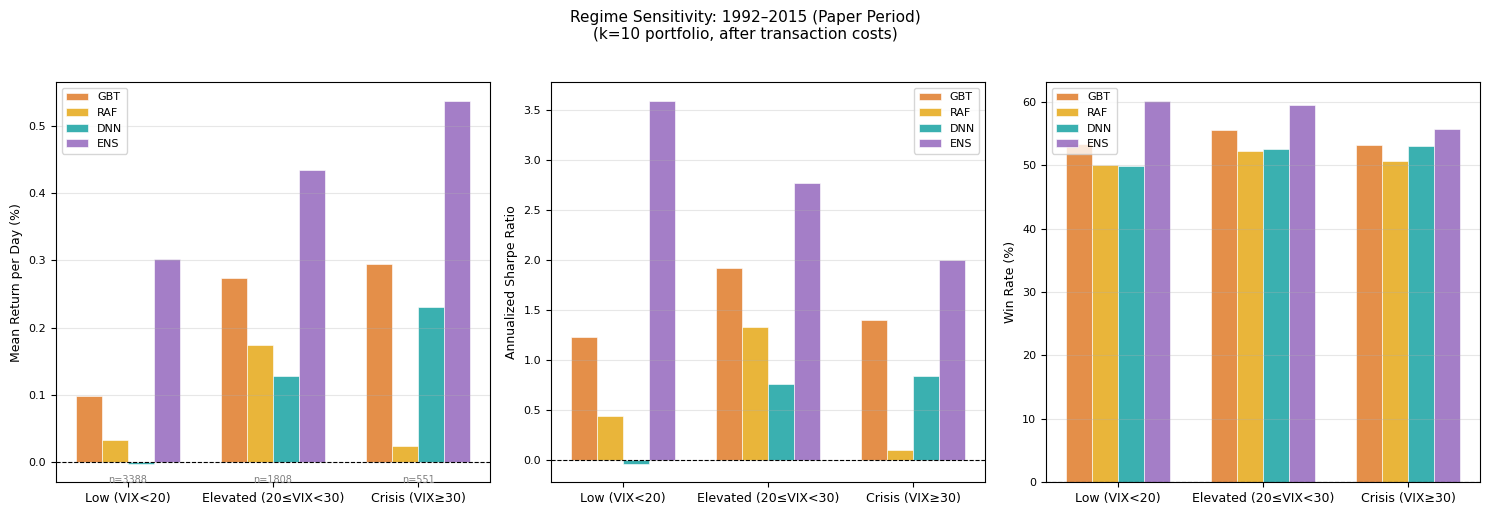

Saved: regime_paper.pdf / .png

新增区间 (2015–2024)
               Regime Model  Mean_ret    Sharpe  Win_rate  N_days
        Low\n(VIX<20)   GBT -0.001984 -2.424827  0.427550    1539
        Low\n(VIX<20)   RAF -0.002296 -3.368530  0.404159    1539
        Low\n(VIX<20)   DNN -0.001927 -1.961047  0.445744    1539
        Low\n(VIX<20)   ENS  0.000072  0.087452  0.507472    1539
Elevated\n(20≤VIX<30)   GBT -0.000520 -0.418546  0.485114     571
Elevated\n(20≤VIX<30)   RAF -0.001903 -1.657334  0.448336     571
Elevated\n(20≤VIX<30)   DNN -0.001331 -0.878293  0.474606     571
Elevated\n(20≤VIX<30)   ENS  0.000792  0.571236  0.539405     571
     Crisis\n(VIX≥30)   GBT  0.002805  1.483894  0.542857     140
     Crisis\n(VIX≥30)   RAF -0.001162 -0.741997  0.450000     140
     Crisis\n(VIX≥30)   DNN  0.000147  0.057264  0.507143     140
     Crisis\n(VIX≥30)   ENS  0.004917  2.492005  0.578571     140


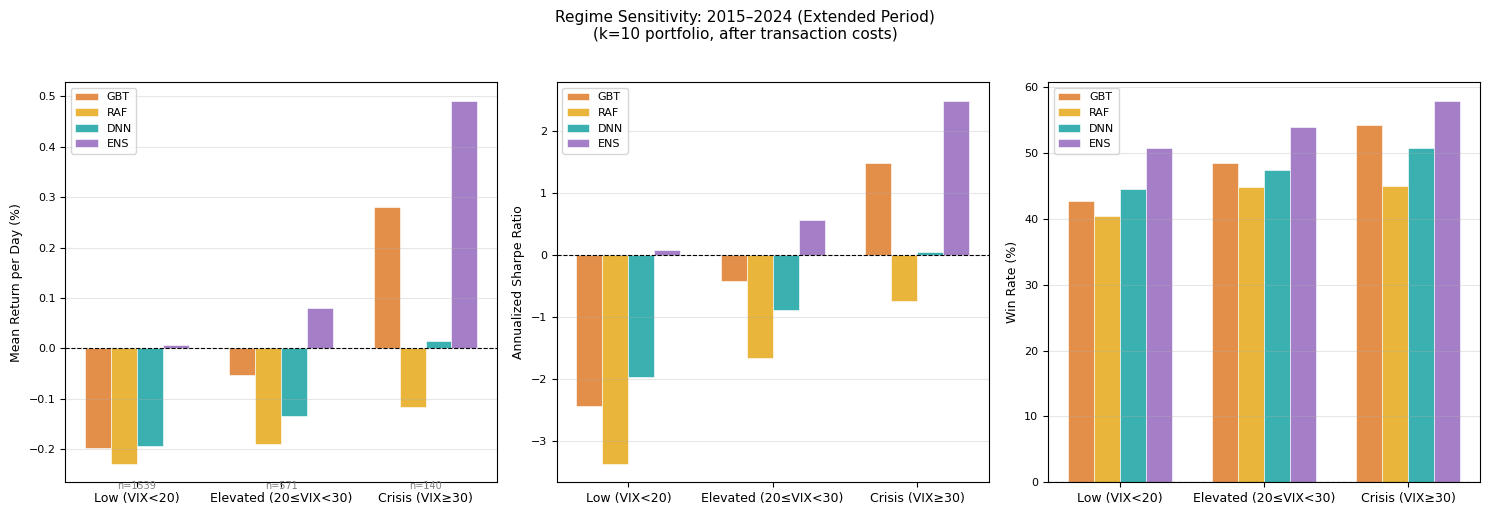

Saved: regime_extended.pdf / .png


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

models       = ["GBT", "RAF", "DNN", "ENS"]
regime_order = ["Low\n(VIX<20)", "Elevated\n(20≤VIX<30)", "Crisis\n(VIX≥30)"]
colors_model = {
    "ENS": "#9467bd",
    "RAF": "#e6a817",
    "GBT": "#e07b29",
    "DNN": "#17a3a3",
}

def compute_results(data):
    rows = []
    for regime in regime_order:
        sub = data[data["regime"] == regime]
        for model in models:
            ret    = sub[model]
            mean_r = ret.mean()
            std_r  = ret.std()
            sharpe = mean_r / std_r * np.sqrt(252) if std_r > 0 else np.nan
            rows.append({
                "Regime"   : regime,
                "Model"    : model,
                "Mean_ret" : mean_r,
                "Sharpe"   : sharpe,
                "Win_rate" : (ret > 0).mean(),
                "N_days"   : len(ret),
            })
    return pd.DataFrame(rows)

def plot_regime(results_df, data, title, figname):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=11, y=1.02)

    metrics = [
        ("Mean_ret", "Mean Return per Day (%)", lambda x: x*100),
        ("Sharpe",   "Annualized Sharpe Ratio", lambda x: x),
        ("Win_rate", "Win Rate (%)",            lambda x: x*100),
    ]

    x     = np.arange(len(regime_order))
    width = 0.18

    for ax, (metric, ylabel, transform) in zip(axes, metrics):
        for j, model in enumerate(models):
            vals = [
                transform(results_df[
                    (results_df["Regime"]==r) &
                    (results_df["Model"]==model)
                ][metric].values[0])
                for r in regime_order
            ]
            offset = (j - 1.5) * width
            ax.bar(x + offset, vals, width,
                   label=model, color=colors_model[model],
                   alpha=0.85, edgecolor="white", lw=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels([r.replace("\n"," ") for r in regime_order], fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.legend(fontsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(axis='y', alpha=0.3)

        if metric == "Mean_ret":
            ymin = ax.get_ylim()[0]
            for xi, regime in zip(x, regime_order):
                n = data[data["regime"]==regime].shape[0]
                ax.text(xi, ymin * 1.05, f"n={n}",
                        ha='center', fontsize=7, color='gray')

    plt.tight_layout()
    plt.savefig(f"{figname}.pdf", bbox_inches="tight", dpi=150)
    plt.savefig(f"{figname}.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {figname}.pdf / .png")

# ── 分组 ──────────────────────────────────────────────────────
def assign_regime(v):
    if v < 20:   return "Low\n(VIX<20)"
    elif v < 30: return "Elevated\n(20≤VIX<30)"
    else:        return "Crisis\n(VIX≥30)"

df["regime"] = df["vix"].apply(assign_regime)

# ── 论文区间 1992-2015 ────────────────────────────────────────
df_paper = df[df["date"] <= "2015-10-14"].copy()
res_paper = compute_results(df_paper)

print("="*60)
print("论文区间 (1992–2015)")
print("="*60)
print(res_paper.to_string(index=False))

plot_regime(
    res_paper, df_paper,
    title="Regime Sensitivity: 1992–2015 (Paper Period)\n"
          "(k=10 portfolio, after transaction costs)",
    figname="regime_paper"
)

# ── 新增区间 2015-2024 ────────────────────────────────────────
df_new = df[df["date"] > "2015-10-14"].copy()
res_new = compute_results(df_new)

print("\n" + "="*60)
print("新增区间 (2015–2024)")
print("="*60)
print(res_new.to_string(index=False))

plot_regime(
    res_new, df_new,
    title="Regime Sensitivity: 2015–2024 (Extended Period)\n"
          "(k=10 portfolio, after transaction costs)",
    figname="regime_extended"
)